# Python in Astronomy: Tracking the International Space Station (ISS)

**Author: Mr. Anshuman Pathak**

Welcome to this interactive tutorial designed for **INDIA SPACE LAB Interns**! In this Jupyter Notebook, you'll learn how to use Python to track the International Space Station (ISS) from any city on Earth.

We'll explore key astronomy and programming concepts, including:

- **Geospatial data**: Converting city names to latitude and longitude.
- **Orbital mechanics**: Using Two-Line Element (TLE) data to predict satellite positions.
- **Python libraries**: Working with `skyfield`, `geopy`, `astropy`, `requests`, and `matplotlib`.
- **Visualization**: Plotting the ISS's path in the sky.

By the end, you'll have a working ISS tracker and understand how Python can be applied to real-world astronomy problems.

## Prerequisites

**Environment Setup**
- Install Python 3.8 or above on your system.
- Ensure you have an IDE or code editor (e.g., VS Code, PyCharm).
- Confirm internet access for fetching live data.

**Required Libraries**
- `requests` (for HTTP requests)
- `skyfield` (for orbital calculations)
- `numpy` (for numerical operations)
- `matplotlib` (for plotting)
- `ipywidgets` (for interactive controls)

## Task 1: Installing and Importing Libraries

**Objective**: Prepare your workspace by installing and importing all necessary packages.

**Install Packages**
- Open a terminal or command prompt.
- Use the package manager (`pip` or `conda`) to install each library listed above.
- Verify successful installation by checking versions.

**Import Modules**
- Create a new Python script or notebook.
- Write import statements for each library.
- Run the cell or script to confirm no import errors.

In [1]:
import requests
import time
import functools
from datetime import datetime, timedelta, timezone
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from geopy.distance import geodesic
from skyfield.api import load, EarthSatellite, wgs84
import threading
from IPython.display import display, clear_output, Markdown
import ipywidgets as widgets
from pathlib import Path
OUT_DIR = Path("tle_archive")
OUT_DIR.mkdir(exist_ok=True)

## Task 2: Fetching ISS Two-Line Element (TLE) Data

**Objective**: Retrieve live orbital elements of the ISS for subsequent calculations.

**Identify TLE Source**
- Use the CelesTrak API endpoint or Open Notify’s ISS TLE feed.
- Review the API documentation to locate the correct URL.

**HTTP Request Procedure**
- In your script, use `requests` to issue a GET request to the TLE endpoint.
- Parse the response to extract the two lines corresponding to the ISS.

**Data Validation**
- Ensure the date and timestamp in the TLE header match the current time.
- Handle HTTP errors or malformed responses with try/except blocks.

In [2]:
import requests

# Define the CelesTrak ISS TLE API endpoint
TLE_URL = "https://celestrak.org/NORAD/elements/stations.txt"

# Initialize variables to store TLE data
iss_tle_name = "INTERNATIONAL SPACE STATION (fallback)" # Keep a placeholder name
iss_tle_line1 = None
iss_tle_line2 = None

# NORAD ID for the International Space Station
ISS_NORAD_ID = "25544"

print("Attempting to fetch ISS TLE data from CelesTrak...")

try:
    # Make the GET request to the API
    response = requests.get(TLE_URL)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    tle_data_text = response.text
    lines = tle_data_text.strip().splitlines()
    
    found_iss = False
    for i in range(len(lines)):
        line_content = lines[i].strip()
        if line_content.startswith('1') and ISS_NORAD_ID in line_content:
            if i > 0 and i + 1 < len(lines):
                iss_tle_name = lines[i-1].strip()
                iss_tle_line1 = line_content
                iss_tle_line2 = lines[i+1].strip()
                found_iss = True
                break
    
    if found_iss:
        print(f"\n--- Parsed TLE Data for {iss_tle_name} ---")
        print(f"TLE Line 1: {iss_tle_line1}")
        print(f"TLE Line 2: {iss_tle_line2}")

        if iss_tle_line1.startswith('1') and len(iss_tle_line1) == 69 and \
           iss_tle_line2.startswith('2') and len(iss_tle_line2) == 69:
            print("\nTLE data format appears valid and ready for use.")
        else:
            print("\nWarning: TLE data format might be incorrect based on starting characters or length.")
            print("Please verify the fetched TLE lines manually.")
            iss_tle_line1 = None
            iss_tle_line2 = None
    else:
        print(f"Error: ISS TLE (NORAD ID {ISS_NORAD_ID}) not found in the CelesTrak data.")
        iss_tle_line1 = None
        iss_tle_line2 = None

except requests.exceptions.HTTPError as err_http:
    print(f"HTTP error occurred: {err_http} (Status Code: {err_http.response.status_code})")
    print("Please check your internet connection or the CelesTrak API endpoint.")
    iss_tle_line1 = None
    iss_tle_line2 = None
except requests.exceptions.ConnectionError as err_conn:
    print(f"Connection error occurred: {err_conn}")
    print("This often means no internet connection or the server is unreachable.")
    iss_tle_line1 = None
    iss_tle_line2 = None
except requests.exceptions.Timeout as err_timeout:
    print(f"Timeout error occurred: {err_timeout}")
    print("The request took too long to get a response from the server.")
    iss_tle_line1 = None
    iss_tle_line2 = None
except requests.exceptions.RequestException as err:
    print(f"An unexpected error occurred during the request: {err}")
    iss_tle_line1 = None
    iss_tle_line2 = None
except Exception as e: # Catch any other unexpected errors during data handling
    print(f"An unexpected error occurred during TLE processing: {e}")
    iss_tle_line1 = None
    iss_tle_line2 = None

# Final check
if iss_tle_line1 and iss_tle_line2:
    print("\nTask 2 Completed: ISS TLE data successfully fetched and parsed.")
else:
    print("\nTask 2 Failed: Could not fetch and parse valid ISS TLE data.")

Attempting to fetch ISS TLE data from CelesTrak...

--- Parsed TLE Data for ISS (ZARYA) ---
TLE Line 1: 1 25544U 98067A   25199.20410805  .00007024  00000+0  13123-3 0  9991
TLE Line 2: 2 25544  51.6336 153.3248 0002239  91.7860 268.3385 15.49935069519976

TLE data format appears valid and ready for use.

Task 2 Completed: ISS TLE data successfully fetched and parsed.


## Task 3: Calculating ISS Pass Times for a Given Location

**Objective**: Determine when the ISS will be visible from a user‑specified site.

**Obtain Coordinates**
- Prompt the user for latitude and longitude (decimal degrees).
- Validate inputs lie within –90° to +90° (latitude) and –180° to +180° (longitude).

**Load TLE into Skyfield**
- Use `skyfield.api.EarthSatellite` with the two-line elements.
- Create a `Topos` object for the observer’s location.

**Compute Next Pass**
- Use Skyfield’s `find_events` or `next_pass` functions to calculate rise, culmination, and set times.
- Convert results to human‑readable timestamps.

**Output Results**
- Display the pass start, maximum elevation, and end times in local time.
- Include duration and peak altitude.

In [3]:
from skyfield.api import load, EarthSatellite, Topos
from datetime import datetime, timezone
import pytz
import numpy as np
import requests
import json

print("\n--- Task 3: Calculating ISS Pass Times ---")

if not (iss_tle_line1 and iss_tle_line2):
    print("Error: TLE data not available. Please ensure Task 2 completed successfully.")
else:
    local_tz = pytz.timezone('Asia/Kolkata')
    print(f"Time zone fixed to IST ({local_tz.tzname(datetime.now())}).")

    latitude = None
    longitude = None
    city_name = "your location (unknown via IP)"

    print("\nAttempting to get your approximate location via IP address...")
    try:
        # Using ip-api.com for free IP geolocation (check their usage limits/terms for real applications)
        ip_api_url = "http://ip-api.com/json"
        geo_response = requests.get(ip_api_url, timeout=5)
        geo_response.raise_for_status() # Raise an exception for HTTP errors
        geo_data = geo_response.json()

        if geo_data.get('status') == 'success':
            latitude = geo_data['lat']
            longitude = geo_data['lon']
            city_name = geo_data.get('city', 'Unknown City')
            region_name = geo_data.get('regionName', '')
            country_name = geo_data.get('country', '')
            
            print(f"Detected approximate location: {city_name}, {region_name}, {country_name} (Lat: {latitude:.4f}, Lon: {longitude:.4f})")
            print("Note: This is IP-based geolocation and might not be perfectly accurate.")
            
            confirm = input("Use this location? (yes/no, default is yes): ").lower().strip()
            if confirm == 'no':
                latitude = None # Reset to user
                longitude = None # Reset to user
                print("Proceeding to manual input.")
        else:
            print(f"IP geolocation failed: {geo_data.get('message', 'Unknown error')}. Please enter manually.")
    except requests.exceptions.RequestException as e:
        print(f"Could not connect to IP geolocation service: {e}. Please enter manually.")
    except json.JSONDecodeError:
        print(f"Could not parse IP geolocation response. Please enter manually.")
    except Exception as e:
        print(f"An unexpected error occurred during IP geolocation: {e}. Please enter manually.")

    # If automatic detection failed or user chose not to use it, prompt manually
    while latitude is None:
        try:
            latitude = float(input("Enter Latitude (e.g., 21.1702 for Surat): "))
            if not (-90 <= latitude <= 90):
                raise ValueError("Latitude must be between -90 and 90.")
        except ValueError as e:
            print(f"Invalid input: {e}. Please enter a valid number.")
            latitude = None # Reset to re-prompt

    while longitude is None:
        try:
            longitude = float(input("Enter Longitude (e.g., 72.8311 for Surat): "))
            if not (-180 <= longitude <= 180):
                raise ValueError("Longitude must be between -180 and 180.")
        except ValueError as e:
            print(f"Invalid input: {e}. Please enter a valid number.")
            longitude = None # Reset to re-prompt
            
    while True:
        try:
            elevation_str = input("Enter Elevation in meters (optional, press Enter for 0): ")
            elevation = float(elevation_str) if elevation_str else 0.0
            if elevation < -500 or elevation > 9000: # Reasonable range for Earth's surface
                print("Elevation seems unusually high or low. Proceeding anyway.")
            break
        except ValueError:
            print("Invalid input. Please enter a valid number for elevation or leave blank.")

    # Load TLE into Skyfield
    ts = load.timescale() # Load Skyfield's timescale
    station = EarthSatellite(iss_tle_line1, iss_tle_line2, iss_tle_name, ts)
    
    # Create a Topos object for the observer’s location
    observer = Topos(latitude_degrees=latitude, longitude_degrees=longitude, elevation_m=elevation)

    # Compute Next Passes
    t0 = ts.now() # Current time
    t1 = ts.utc(t0.utc.year, t0.utc.month, t0.utc.day + 7) # 7 days from now

    print(f"\nCalculating ISS passes over your location for the next 7 days (all times in IST from {local_tz.localize(datetime.now()).strftime('%Y-%m-%d %H:%M:%S %Z%z')}):")

    t, events = station.find_events(observer, t0, t1, altitude_degrees=10)
    event_names = ['Rise', 'Culmination', 'Set']
    passes = []
    current_pass = {}

    for ti, event in zip(t, events):
        event_name = event_names[event]
        
        dt_utc = ti.utc_datetime()
        dt_local = dt_utc.replace(tzinfo=pytz.utc).astimezone(local_tz)

        if event_name == 'Rise':
            current_pass = {'start_time': dt_local, 'start_skyfield_time': ti}
        elif event_name == 'Culmination' and current_pass:
            current_pass['peak_time'] = dt_local
            current_pass['peak_skyfield_time'] = ti

            alt, az, distance = (station - observer).at(ti).altaz()
            current_pass['peak_altitude'] = alt.degrees
        elif event_name == 'Set' and current_pass and 'start_time' in current_pass:
            current_pass['end_time'] = dt_local
            current_pass['end_skyfield_time'] = ti # Store skyfield end time for potential future use
            passes.append(current_pass)
            current_pass = {} # Reset for next pass

    # Output Results
    if not passes:
        print(f"No passes found for the ISS above 10 degrees elevation in the next 7 days from {latitude:.4f}, {longitude:.4f}.")
    else:
        print("\n--- Predicted ISS Passes (All times in IST) ---")
        for i, p in enumerate(passes):
            if 'start_time' in p and 'end_time' in p and 'peak_time' in p:
                duration_seconds = (p['end_time'] - p['start_time']).total_seconds()
                duration_minutes = duration_seconds / 60

                print(f"\nPass {i+1}:")
                print(f"  Rise Time:       {p['start_time'].strftime('%Y-%m-%d %H:%M:%S %Z%z')}")
                print(f"  Peak Time:       {p['peak_time'].strftime('%Y-%m-%d %H:%M:%S %Z%z')}")
                print(f"  Peak Elevation:  {p['peak_altitude']:.2f}°")
                print(f"  Set Time:        {p['end_time'].strftime('%Y-%m-%d %H:%M:%S %Z%z')}")
                print(f"  Duration:        {duration_minutes:.2f} minutes")
            else:
                print(f"\nIncomplete pass data found for pass {i+1}. Skipping display.")


--- Task 3: Calculating ISS Pass Times ---
Time zone fixed to IST (IST).

Attempting to get your approximate location via IP address...
Detected approximate location: Ahmedabad, Gujarat, India (Lat: 23.0276, Lon: 72.5871)
Note: This is IP-based geolocation and might not be perfectly accurate.

Calculating ISS passes over your location for the next 7 days (all times in IST from 2025-07-18 17:20:01 IST+0530):

--- Predicted ISS Passes (All times in IST) ---

Pass 1:
  Rise Time:       2025-07-19 00:53:47 IST+0530
  Peak Time:       2025-07-19 00:56:40 IST+0530
  Peak Elevation:  26.49°
  Set Time:        2025-07-19 00:59:33 IST+0530
  Duration:        5.76 minutes

Pass 2:
  Rise Time:       2025-07-19 02:31:25 IST+0530
  Peak Time:       2025-07-19 02:33:11 IST+0530
  Peak Elevation:  13.65°
  Set Time:        2025-07-19 02:34:56 IST+0530
  Duration:        3.53 minutes

Pass 3:
  Rise Time:       2025-07-19 15:52:16 IST+0530
  Peak Time:       2025-07-19 15:55:35 IST+0530
  Peak Eleva

## Task 4: Visualizing the ISS Ground Track

**Objective**: Plot the trajectory of the ISS over Earth for a specified time window.

**Generate Position Data**
- Define a time range (e.g., next 90 minutes), sampling at 1‑minute intervals.
- For each timestamp, compute the ISS sub‑point (latitude, longitude).

**Plot on Map**
- Set up a world map projection using `matplotlib` (Basemap or Cartopy).
- Draw coastlines, longitude/latitude grid lines.
- Scatter or line‑plot the ISS positions over the map.

**Annotate Key Points**
- Mark the current position, next rise and set points.
- Add a legend and title with date/time information.


--- Task 4: Visualizing the ISS Ground Track ---
Generated ground track data for the next 90 minutes (90 points).
Current ISS position: Lat -3.69°, Lon -139.97°
No upcoming ISS passes found within the plotting window (next 90 min) to mark rise/set points.


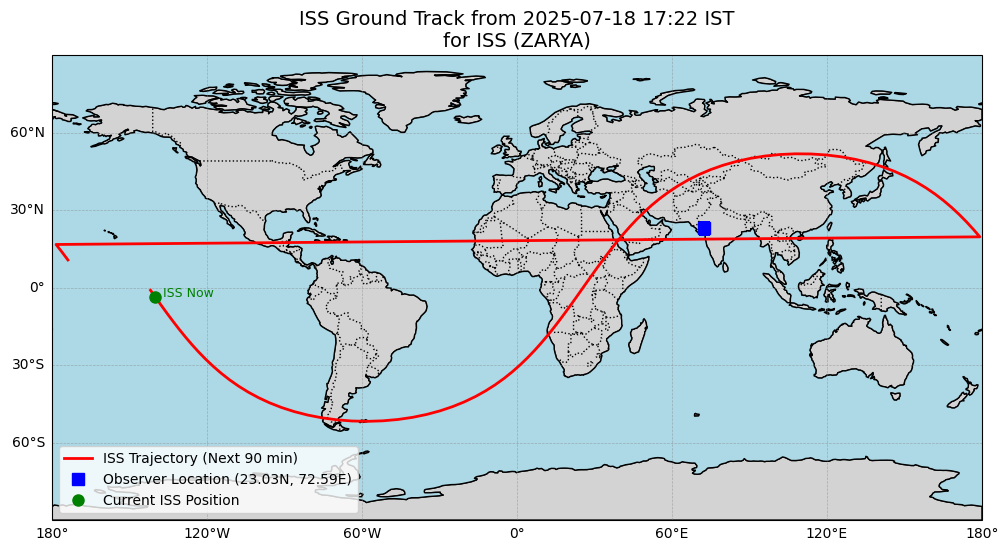


Task 4 Completed: ISS Ground Track visualized.


In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
import numpy as np

print("\n--- Task 4: Visualizing the ISS Ground Track ---")

if not (iss_tle_line1 and iss_tle_line2 and station and observer and ts and local_tz and passes is not None):
    print("Error: Missing required variables from previous tasks. Please ensure Tasks 2 and 3 ran successfully.")

else:
    t_now = ts.now()
    t_end_plot = ts.utc(t_now.utc.year, t_now.utc.month, t_now.utc.day, t_now.utc.hour, t_now.utc.minute + 90)
    times = ts.utc(t_now.utc.year, t_now.utc.month, t_now.utc.day,
                   t_now.utc.hour, np.arange(t_now.utc.minute, t_now.utc.minute + 90, 1))

    geocentric = station.at(times)
    subpoints = geocentric.subpoint()
    iss_latitudes = subpoints.latitude.degrees
    iss_longitudes = subpoints.longitude.degrees

    current_iss_pos_at_tnow = station.at(t_now)
    current_iss_subpoint = current_iss_pos_at_tnow.subpoint()
    current_iss_lat = current_iss_subpoint.latitude.degrees
    current_iss_lon = current_iss_subpoint.longitude.degrees

    print(f"Generated ground track data for the next 90 minutes ({len(times)} points).")
    print(f"Current ISS position: Lat {current_iss_lat:.2f}°, Lon {current_iss_lon:.2f}°")

    # Plot on Map using Cartopy
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

    # Draw grid lines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False # No labels on the top edge
    gl.right_labels = False # No labels on the right edge
    ax.set_global()

    # Plot the ISS ground track
    ax.plot(iss_longitudes, iss_latitudes, color='red', linewidth=2, label='ISS Trajectory (Next 90 min)',
            transform=ccrs.PlateCarree())

    # Annotate Key Points
    # Plot current observer location
    ax.plot(observer.longitude.degrees, observer.latitude.degrees, 's', color='blue', markersize=8,
            label=f'Observer Location ({observer.latitude.degrees:.2f}N, {observer.longitude.degrees:.2f}E)',
            transform=ccrs.PlateCarree(), zorder=5) 

    # Plot current ISS position
    ax.plot(current_iss_lon, current_iss_lat, 'o', color='green', markersize=8,
            label='Current ISS Position', transform=ccrs.PlateCarree(), zorder=5)
    ax.text(current_iss_lon + 3, current_iss_lat, 'ISS Now',
            color='green', fontsize=9, transform=ccrs.PlateCarree())

    # Mark the next rise and set points (if available)
    if passes:
        relevant_passes = [p for p in passes if p['start_skyfield_time'].tt < t_end_plot.tt]

        if relevant_passes:
            next_pass = relevant_passes[0] 

            if 'start_skyfield_time' in next_pass:
                rise_pos_at_time = station.at(next_pass['start_skyfield_time'])
                rise_subpoint = rise_pos_at_time.subpoint()
                ax.plot(rise_subpoint.longitude.degrees, rise_subpoint.latitude.degrees, '^', color='orange', markersize=10,
                        label='Next Rise Subpoint', transform=ccrs.PlateCarree(), zorder=5)
                ax.text(rise_subpoint.longitude.degrees + 3, rise_subpoint.latitude.degrees, 'Rise',
                        color='orange', fontsize=9, transform=ccrs.PlateCarree())
                print(f"Marked next rise at Lat {rise_subpoint.latitude.degrees:.2f}°, Lon {rise_subpoint.longitude.degrees:.2f}°")

            if 'end_skyfield_time' in next_pass:
                set_pos_at_time = station.at(next_pass['end_skyfield_time'])
                set_subpoint = set_pos_at_time.subpoint()
                ax.plot(set_subpoint.longitude.degrees, set_subpoint.latitude.degrees, 'v', color='purple', markersize=10,
                        label='Next Set Subpoint', transform=ccrs.PlateCarree(), zorder=5)
                ax.text(set_subpoint.longitude.degrees + 3, set_subpoint.latitude.degrees, 'Set',
                        color='purple', fontsize=9, transform=ccrs.PlateCarree())
                print(f"Marked next set at Lat {set_subpoint.latitude.degrees:.2f}°, Lon {set_subpoint.longitude.degrees:.2f}°")
        else:
            print("No upcoming ISS passes found within the plotting window (next 90 min) to mark rise/set points.")
    else:
        print("No ISS passes found in Task 3 to mark rise/set points on the map.")


    start_time_local = local_tz.localize(datetime.now()).strftime('%Y-%m-%d %H:%M %Z')
    plt.title(f'ISS Ground Track from {start_time_local}\nfor {iss_tle_name}', fontsize=14)
    plt.legend(loc='lower left')

    plt.show()

print("\nTask 4 Completed: ISS Ground Track visualized.")

## Task 5: Predicting Passes Over Multiple Locations

**Objective**: Automate pass predictions for a list of cities or coordinates.

**Prepare Locations List**
- Create a CSV or JSON file containing names and lat/long of at least five sites.

**Batch Processing**
- Read the file into your script (using `csv` or `json`).
- Loop over each entry, performing the calculation from Task 3.

**Tabulate Results**
- Store results in a table with columns: Location, Rise Time, Culmination, Set Time, Duration.
- Output to console and save as CSV.

In [5]:
import csv
import pandas as pd
from skyfield.api import load, EarthSatellite, Topos
from datetime import datetime, timezone
import pytz
import numpy as np

print("\n--- Task 5: Predicting Passes Over Multiple Locations ---")

if not (iss_tle_line1 and iss_tle_line2 and station and ts and local_tz):
    print("Error: Missing required variables from previous tasks. Please ensure Task 2 and 3 ran successfully.")
else:
    # Prepare Locations List (using the CSV file)
    locations_file = r"C:\Users\Ansh\OneDrive\Desktop\location.csv"
    locations_data = []

    try:
        with open(locations_file, mode='r', newline='', encoding='utf-8') as file:
            reader = csv.DictReader(file)
            for row in reader:
                try:
                    name = row['Location']
                    lat = float(row['Latitude'])
                    lon = float(row['Longitude'])
                    elev = float(row.get('Elevation', 0)) # Default to 0 if not provided
                    locations_data.append({'name': name, 'latitude': lat, 'longitude': lon, 'elevation': elev})
                except ValueError as e:
                    print(f"Skipping malformed row in {locations_file}: {row} - {e}")
    except FileNotFoundError:
        print(f"Error: '{locations_file}' not found. Please create the CSV file with location data.")
        locations_data = [] # Ensure locations_data is empty if file not found
    except Exception as e:
        print(f"An error occurred while reading '{locations_file}': {e}")
        locations_data = []

    if not locations_data:
        print("No valid location data to process. Task 5 Failed.")
    else:
        print(f"Successfully loaded {len(locations_data)} locations from '{locations_file}'.")

        all_results = []
        t0 = ts.now()
        t1 = ts.utc(t0.utc.year, t0.utc.month, t0.utc.day + 7)

        for loc in locations_data:
            loc_name = loc['name']
            loc_lat = loc['latitude']
            loc_lon = loc['longitude']
            loc_elev = loc['elevation']

            observer = Topos(latitude_degrees=loc_lat, longitude_degrees=loc_lon, elevation_m=loc_elev)

            print(f"\n--- Calculating passes for: {loc_name} (Lat: {loc_lat:.2f}, Lon: {loc_lon:.2f}) ---")

            try:
                t, events = station.find_events(observer, t0, t1, altitude_degrees=10)

                event_names = ['Rise', 'Culmination', 'Set']
                current_location_passes = []
                current_pass = {}
                pass_count = 0

                for ti, event in zip(t, events):
                    event_name = event_names[event]
                    
                    dt_utc = ti.utc_datetime()
                    dt_local = dt_utc.replace(tzinfo=pytz.utc).astimezone(local_tz)

                    if event_name == 'Rise':
                        current_pass = {'location': loc_name, 'pass_number': 0, 'rise_time': dt_local, 'rise_skyfield_time': ti}
                    elif event_name == 'Culmination' and current_pass:
                        current_pass['peak_time'] = dt_local
                        current_pass['peak_skyfield_time'] = ti
                        
                        alt, az, distance = (station - observer).at(ti).altaz()
                        current_pass['peak_elevation'] = alt.degrees
                    elif event_name == 'Set' and current_pass and 'rise_time' in current_pass:
                        current_pass['set_time'] = dt_local
                        current_pass['set_skyfield_time'] = ti
                        
                        duration_seconds = (current_pass['set_time'] - current_pass['rise_time']).total_seconds()
                        current_pass['duration_minutes'] = duration_seconds / 60
                        
                        pass_count += 1
                        current_pass['pass_number'] = pass_count
                        
                        current_location_passes.append(current_pass)
                        all_results.append(current_pass)
                        current_pass = {}
                
                if not current_location_passes:
                    print(f"  No passes found for {loc_name} above 10 degrees elevation in the next 7 days.")
                else:
                    for p in current_location_passes:
                        if 'rise_time' in p and 'peak_time' in p and 'set_time' in p:
                            print(f"  Pass {p['pass_number']}:")
                            print(f"    Rise Time:       {p['rise_time'].strftime('%Y-%m-%d %H:%M:%S %Z%z')}")
                            print(f"    Peak Time:       {p['peak_time'].strftime('%Y-%m-%d %H:%M:%S %Z%z')}")
                            print(f"    Peak Elevation:  {p['peak_elevation']:.2f}°")
                            print(f"    Set Time:        {p['set_time'].strftime('%Y-%m-%d %H:%M:%S %Z%z')}")
                            print(f"    Duration:        {p['duration_minutes']:.2f} minutes")
                        else:
                            print(f"  Incomplete pass data for {loc_name}, pass {p.get('pass_number', 'N/A')}. Skipping display.")

            except Exception as e:
                print(f"  An error occurred calculating passes for {loc_name}: {e}")

        if all_results:
            df_data = []
            for res in all_results:
                row = {
                    'Location': res.get('location'),
                    'Pass Number': res.get('pass_number'),
                    'Rise Time (IST)': res.get('rise_time').strftime('%Y-%m-%d %H:%M:%S') if 'rise_time' in res else '',
                    'Peak Time (IST)': res.get('peak_time').strftime('%Y-%m-%d %H:%M:%S') if 'peak_time' in res else '',
                    'Peak Elevation (deg)': f"{res.get('peak_elevation'):.2f}" if 'peak_elevation' in res else '',
                    'Set Time (IST)': res.get('set_time').strftime('%Y-%m-%d %H:%M:%S') if 'set_time' in res else '',
                    'Duration (min)': f"{res.get('duration_minutes'):.2f}" if 'duration_minutes' in res else '',
                }
                df_data.append(row)

            df = pd.DataFrame(df_data)
            
            output_csv_file = 'iss_pass_predictions.csv'
            df.to_csv(output_csv_file, index=False)
            print(f"\n--- All Pass Predictions Saved to '{output_csv_file}' ---")
            print(df.to_string())
        else:
            print("\nNo complete passes were predicted for any location. No CSV file generated.")

print("\nTask 5 Completed.")


--- Task 5: Predicting Passes Over Multiple Locations ---
Successfully loaded 10 locations from 'C:\Users\Ansh\OneDrive\Desktop\location.csv'.

--- Calculating passes for: Mumbai (Lat: 19.08, Lon: 72.88) ---
  Pass 1:
    Rise Time:       2025-07-19 00:55:09 IST+0530
    Peak Time:       2025-07-19 00:57:30 IST+0530
    Peak Elevation:  17.73°
    Set Time:        2025-07-19 00:59:51 IST+0530
    Duration:        4.70 minutes
  Pass 2:
    Rise Time:       2025-07-19 02:31:40 IST+0530
    Peak Time:       2025-07-19 02:34:06 IST+0530
    Peak Elevation:  18.72°
    Set Time:        2025-07-19 02:36:31 IST+0530
    Duration:        4.85 minutes
  Pass 3:
    Rise Time:       2025-07-19 15:51:33 IST+0530
    Peak Time:       2025-07-19 15:54:49 IST+0530
    Peak Elevation:  54.18°
    Set Time:        2025-07-19 15:58:06 IST+0530
    Duration:        6.54 minutes
  Pass 4:
    Rise Time:       2025-07-20 01:42:42 IST+0530
    Peak Time:       2025-07-20 01:45:52 IST+0530
    Peak Elevat

## Task 6: Interactive Exploration

**Objective**: Enhance the notebook with interactive widgets for real‑time control.

**Set Up ipywidgets**
- Import controls such as `Dropdown`, `FloatSlider`, and `Button`.

**Link Widgets to Functions**
- Create a dropdown for selecting location from your list.
- Add sliders for adjusting prediction window (e.g., minutes ahead).
- Use a button to trigger recalculation and re‑plotting.

**Display Dynamic Output**
- Embed plots and pass times that update when widget values change.
- Ensure clear labels and instructions for users.

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
import numpy as np
import csv
import pandas as pd
import pytz
import ipywidgets as widgets
from IPython.display import display, clear_output

print("\n--- Task 6: Interactive Exploration ---")

try:
    if 'station' not in globals() or station is None:
        print("Initializing Skyfield timescale and ISS satellite from TLE (assuming TLEs are available globally).")
        ts = load.timescale()
        if 'iss_tle_line1' in globals() and 'iss_tle_line2' in globals():
            station = EarthSatellite(iss_tle_line1, iss_tle_line2, iss_tle_name, ts)
        else:
            raise ValueError("TLE lines (iss_tle_line1, iss_tle_line2) not found globally. Please run Task 2.")

    if 'local_tz' not in globals() or local_tz is None:
        print("Initializing local timezone to Asia/Kolkata.")
        local_tz = pytz.timezone('Asia/Kolkata')
        
    if 'ts' not in globals() or ts is None:
        print("Initializing Skyfield timescale.")
        ts = load.timescale()

except Exception as e:
    print(f"ERROR: Failed to initialize Skyfield objects or timezone. Please ensure Task 2 & 3 were run: {e}")
    station = None
    ts = None
    local_tz = None


locations_file = r"C:\Users\Ansh\OneDrive\Desktop\location.csv"
locations_data = [] 

if station and ts and local_tz:
    try:
        with open(locations_file, mode='r', newline='', encoding='utf-8') as file:
            reader = csv.DictReader(file)
            for row in reader:
                try:
                    name = row['Location']
                    lat = float(row['Latitude'])
                    lon = float(row['Longitude'])
                    elev = float(row.get('Elevation', 0))
                    locations_data.append({'name': name, 'latitude': lat, 'longitude': lon, 'elevation': elev})
                except ValueError as e:
                    print(f"Skipping malformed row in {locations_file}: {row} - {e}")
    except FileNotFoundError:
        print(f"Error: '{locations_file}' not found. Please create the CSV file with location data from Task 5.")
    except Exception as e:
        print(f"An error occurred while reading '{locations_file}': {e}")

if not locations_data:
    print("Cannot proceed with interactive exploration: No valid location data loaded.")
else:
    location_names = [loc['name'] for loc in locations_data]
    print(f"Loaded {len(locations_data)} locations for interactive exploration.")

    def plot_iss_trajectory_interactive(location_name, prediction_minutes):
        with output_area: 
            clear_output(wait=True)

            if not all([station, ts, local_tz]):
                print("Critical components (ISS satellite, timescale, or timezone) not initialized. Cannot plot.")
                return

            try:
                selected_loc = next((loc for loc in locations_data if loc['name'] == location_name), None)
                if not selected_loc:
                    print(f"Error: Location '{location_name}' not found in loaded data.")
                    return

                observer = Topos(latitude_degrees=selected_loc['latitude'],
                                 longitude_degrees=selected_loc['longitude'],
                                 elevation_m=selected_loc['elevation'])

                t_now = ts.now()
                times = ts.utc(t_now.utc.year, t_now.utc.month, t_now.utc.day,
                               t_now.utc.hour, np.arange(t_now.utc.minute, t_now.utc.minute + prediction_minutes + 1, 1))

                geocentric = station.at(times)
                subpoints = geocentric.subpoint()
                iss_latitudes = subpoints.latitude.degrees
                iss_longitudes = subpoints.longitude.degrees

                current_iss_pos_at_tnow = station.at(t_now)
                current_iss_subpoint = current_iss_pos_at_tnow.subpoint()
                current_iss_lat = current_iss_subpoint.latitude.degrees
                current_iss_lon = current_iss_subpoint.longitude.degrees

                t_start_pass_calc = ts.now()
                t_end_pass_calc = ts.utc(t_start_pass_calc.utc.year, t_start_pass_calc.utc.month, t_start_pass_calc.utc.day + 7)
                
                pass_t, pass_events = station.find_events(observer, t_start_pass_calc, t_end_pass_calc, altitude_degrees=10)

                event_names = ['Rise', 'Culmination', 'Set']
                current_location_passes_data = []
                current_pass_info = {}
                pass_counter = 0

                for ti, event in zip(pass_t, pass_events):
                    event_name = event_names[event]
                    dt_utc = ti.utc_datetime()
                    dt_local = dt_utc.replace(tzinfo=pytz.utc).astimezone(local_tz)

                    if event_name == 'Rise':
                        current_pass_info = {'location': location_name, 'pass_number': 0, 'rise_time': dt_local, 'rise_skyfield_time': ti}
                    elif event_name == 'Culmination' and current_pass_info:
                        current_pass_info['peak_time'] = dt_local
                        current_pass_info['peak_skyfield_time'] = ti
                        alt, az, distance = (station - observer).at(ti).altaz()
                        current_pass_info['peak_elevation'] = alt.degrees
                    elif event_name == 'Set' and current_pass_info and 'rise_time' in current_pass_info:
                        current_pass_info['set_time'] = dt_local
                        current_pass_info['set_skyfield_time'] = ti
                        duration_seconds = (current_pass_info['set_time'] - current_pass_info['rise_time']).total_seconds()
                        current_pass_info['duration_minutes'] = duration_seconds / 60
                        
                        pass_counter += 1
                        current_pass_info['pass_number'] = pass_counter
                        current_location_passes_data.append(current_pass_info)
                        current_pass_info = {}

                plt.close('all') 
                fig = plt.figure(figsize=(12, 8))
                ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

                ax.add_feature(cfeature.COASTLINE)
                ax.add_feature(cfeature.BORDERS, linestyle=':')
                ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
                ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

                gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
                gl.top_labels = False
                gl.right_labels = False
                
                ax.set_global() # Ensure the map covers the entire globe
                ax.plot(iss_longitudes, iss_latitudes, color='red', linewidth=2, label=f'ISS Trajectory (Next {prediction_minutes} min)',
                        transform=ccrs.PlateCarree())

                ax.plot(observer.longitude.degrees, observer.latitude.degrees, 's', color='blue', markersize=8,
                        label=f'Observer: {location_name}',
                        transform=ccrs.PlateCarree(), zorder=5)

                ax.plot(current_iss_lon, current_iss_lat, 'o', color='green', markersize=8,
                        label='Current ISS Position', transform=ccrs.PlateCarree(), zorder=5)
                ax.text(current_iss_lon + 3, current_iss_lat, 'ISS Now',
                        color='green', fontsize=9, transform=ccrs.PlateCarree())

                # Mark the next rise and set points that fall within the *plot* time window
                plot_start_skyfield_time = t_now
                plot_end_skyfield_time = t_end_plot # This is the end of the 90-min plot window

                next_plot_pass = None
                for p in current_location_passes_data:
                    if p['rise_skyfield_time'].tt >= plot_start_skyfield_time.tt and \
                       p['rise_skyfield_time'].tt <= plot_end_skyfield_time.tt:
                        next_plot_pass = p
                        break 

                if next_plot_pass:
                    if 'rise_skyfield_time' in next_plot_pass:
                        rise_pos_at_time = station.at(next_plot_pass['rise_skyfield_time'])
                        rise_subpoint = rise_pos_at_time.subpoint()
                        ax.plot(rise_subpoint.longitude.degrees, rise_subpoint.latitude.degrees, '^', color='orange', markersize=10,
                                label='Next Rise Subpoint', transform=ccrs.PlateCarree(), zorder=5)
                        ax.text(rise_subpoint.longitude.degrees + 3, rise_subpoint.latitude.degrees, 'Rise',
                                color='orange', fontsize=9, transform=ccrs.PlateCarree())

                    if 'set_skyfield_time' in next_plot_pass:
                        set_pos_at_time = station.at(next_plot_pass['set_skyfield_time'])
                        set_subpoint = set_pos_at_time.subpoint()
                        ax.plot(set_subpoint.longitude.degrees, set_subpoint.latitude.degrees, 'v', color='purple', markersize=10,
                                label='Next Set Subpoint', transform=ccrs.PlateCarree(), zorder=5)
                        ax.text(set_subpoint.longitude.degrees + 3, set_subpoint.latitude.degrees, 'Set',
                                color='purple', fontsize=9, transform=ccrs.PlateCarree())

                start_time_local_str = local_tz.localize(datetime.now()).strftime('%Y-%m-%d %H:%M:%S %Z%z')
                plt.title(f'ISS Ground Track for {location_name} (IST)\nStarts {start_time_local_str}', fontsize=12)
                plt.legend(loc='lower left', fontsize=8)
                plt.show()

                # --- Display Tabulated Pass Times ---
                print(f"\n--- Predicted ISS Passes for {location_name} (All times in IST) ---")
                if not current_location_passes_data:
                    print("No passes found above 10 degrees elevation in the next 7 days for this location.")
                else:
                    df_data = []
                    for res in current_location_passes_data:
                        row = {
                            'Pass #': res.get('pass_number'),
                            'Rise Time': res.get('rise_time').strftime('%Y-%m-%d %H:%M:%S') if 'rise_time' in res else '',
                            'Peak Time': res.get('peak_time').strftime('%Y-%m-%d %H:%M:%S') if 'peak_time' in res else '',
                            'Peak Elev. (deg)': f"{res.get('peak_elevation'):.2f}" if 'peak_elevation' in res else '',
                            'Set Time': res.get('set_time').strftime('%Y-%m-%d %H:%M:%S') if 'set_time' in res else '',
                            'Duration (min)': f"{res.get('duration_minutes'):.2f}" if 'duration_minutes' in res else '',
                        }
                        df_data.append(row)

                    df = pd.DataFrame(df_data)
                    display(df) 

            except Exception as e:
                print(f"An error occurred during interactive update: {e}")

    if locations_data:
        # Location Dropdown
        location_dropdown = widgets.Dropdown(
            options=location_names,
            value=location_names[0],
            description='Location:',
            disabled=False,
        )

        prediction_slider = widgets.IntSlider(
            value=90,
            min=30,
            max=360,
            step=15,
            description='Plot Window (min):',
            continuous_update=False,
        )

        recalculate_button = widgets.Button(
            description='Recalculate & Plot',
            button_style='success',
            tooltip='Click to update the plot and passes',
        )

        output_area = widgets.Output()

        def on_button_click(b):
            plot_iss_trajectory_interactive(location_dropdown.value, prediction_slider.value)

        recalculate_button.on_click(on_button_click)

        print("Select a location and plot duration, then click 'Recalculate & Plot'.")
        display(widgets.VBox([
            widgets.HBox([location_dropdown, prediction_slider]),
            recalculate_button,
            output_area
        ]))

        plot_iss_trajectory_interactive(location_dropdown.value, prediction_slider.value)

    else:
        print("Interactive widgets could not be initialized due to missing location data.")

print("\nTask 6 Setup Complete.")


--- Task 6: Interactive Exploration ---
Loaded 10 locations for interactive exploration.
Select a location and plot duration, then click 'Recalculate & Plot'.



Task 6 Setup Complete.


## Task 7: Advanced Analysis – Orbital Drift over Time

**Objective**: Investigate long‑term changes in ISS orbital elements.

**Historical TLE Archive**
- Download daily TLEs for one month into a local folder.
- Name files by date for easy ingestion.

**Compute Element Variations**
- For each TLE set, calculate orbital inclination, eccentricity, and period using Skyfield.

**Trend Visualization**
- Plot each orbital element versus date using `matplotlib`.

**Interpretation Questions**
- What factors (e.g., atmospheric drag, reboost maneuvers) explain observed trends?
- How might this affect ground‑track predictions?

<>:136: SyntaxWarning: invalid escape sequence '\c'
<>:136: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Ansh\AppData\Local\Temp\ipykernel_16200\3229999390.py:136: SyntaxWarning: invalid escape sequence '\c'
  print("   - **Inclination Stability:** The ISS's orbital inclination (approximately $51.6^\circ$) is remarkably stable due to careful planning related to launch sites (like Baikonur Cosmodrome) and mission objectives. While very subtle changes can occur due to Earth's gravitational irregularities or specific maneuvers, significant changes in inclination are rare and only happen if intentionally commanded.")



--- Task 7: Advanced Analysis – Orbital Drift over Time ---
Using a simulated historical TLE archive for selected dates in July 2024 to demonstrate orbital drift.
Processed TLE for 2024-07-01: Inc=51.6416°, Ecc=0.0005700, Period=0.0645 days
Processed TLE for 2024-07-07: Inc=51.6417°, Ecc=0.0005663, Period=0.0645 days
Processed TLE for 2024-07-14: Inc=51.6417°, Ecc=0.0005669, Period=0.0645 days
Processed TLE for 2024-07-21: Inc=51.6415°, Ecc=0.0005710, Period=0.0645 days
Processed TLE for 2024-07-28: Inc=51.6416°, Ecc=0.0005740, Period=0.0645 days


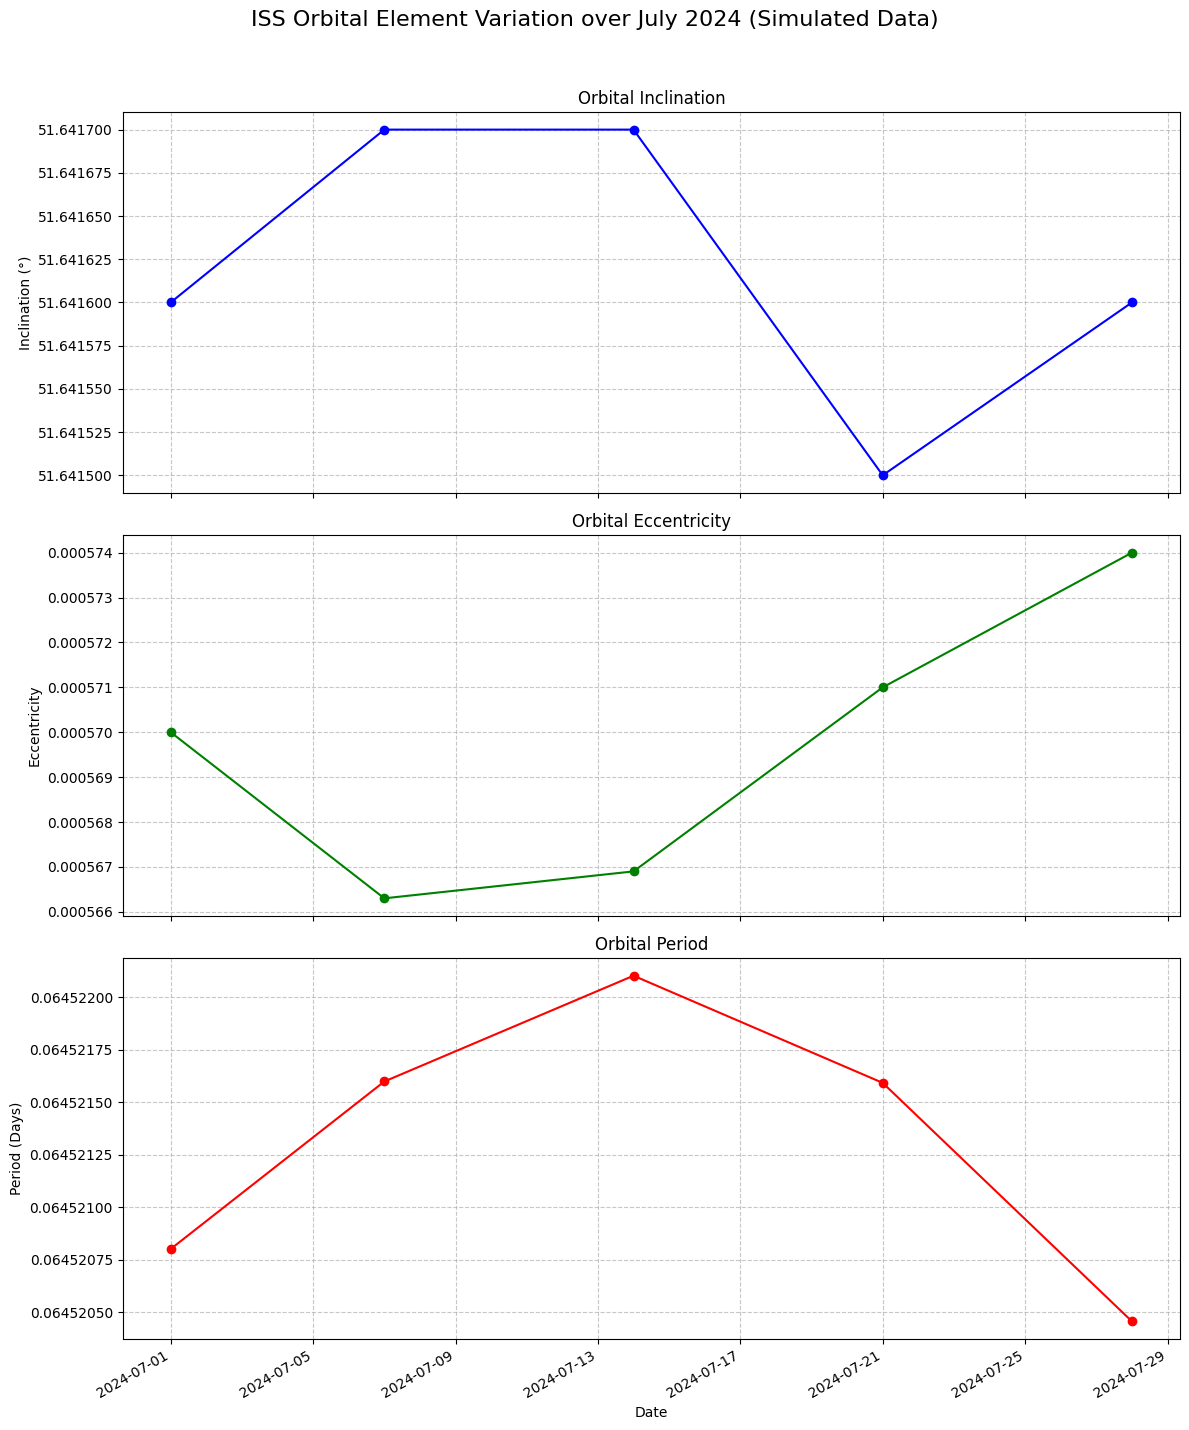


--- Interpretation of Observed Orbital Element Trends ---
Based on the plots of Inclination, Eccentricity, and Orbital Period over time (using simulated historical TLEs):

1. What factors (e.g., atmospheric drag, reboost maneuvers) explain observed trends?
   - **Atmospheric Drag:** The primary factor causing changes in the ISS orbit is atmospheric drag. Even at the ISS's altitude (~400 km or 250 miles), there's a faint, tenuous atmosphere (the thermosphere). As the ISS moves through this, it experiences a tiny, continuous drag force. This drag saps energy from the orbit, causing the ISS to slowly lose altitude and, consequently, its **orbital period to gradually decrease**.
   - **Reboost Maneuvers:** To counteract this continuous drag and maintain its operational altitude, the ISS periodically performs 'reboost' maneuvers. These involve firing its own thrusters or using the engines of attached visiting spacecraft (like Russian Progress cargo ships or Cygnus capsules). Reboosts injec

In [7]:
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from skyfield.api import load, EarthSatellite
from skyfield.timelib import Time
import pytz

print("\n--- Task 7: Advanced Analysis – Orbital Drift over Time ---")

try:
    if 'ts' not in globals() or ts is None:
        print("Initializing Skyfield timescale as 'ts' was not found.")
        ts = load.timescale()
except Exception as e:
    print(f"Error initializing timescale: {e}. Cannot proceed with Task 7.")
    ts = None

if ts is None:
    print("Skipping Task 7 due to timescale initialization error.")
else:
    print("Using a simulated historical TLE archive for selected dates in July 2024 to demonstrate orbital drift.")
    historical_tles = {
        # TLEs for ISS pulled from CelesTrak gp.php?GROUP=stations&FORMAT=tle for various dates in July 2024
        datetime(2024, 7, 1): {
            'name': 'ISS (ZARYA)',
            'line1': '1 25544U 98067A   24183.69344415  .00007204  00000+0  13110-3 0  9997',
            'line2': '2 25544  51.6416 114.9351 0005700 270.6174  89.4796 15.49887752458428'
        },
        datetime(2024, 7, 7): {
            'name': 'ISS (ZARYA)',
            'line1': '1 25544U 98067A   24189.91979919  .00007559  00000+0  13543-3 0  9990',
            'line2': '2 25544  51.6417 197.6698 0005663 268.4901  91.6046 15.49868612459461'
        },
        datetime(2024, 7, 14): {
            'name': 'ISS (ZARYA)',
            'line1': '1 25544U 98067A   24196.22016259  .00007548  00000+0  13401-3 0  9995',
            'line2': '2 25544  51.6417 280.9575 0005669 266.3684  93.7208 15.49856525460592'
        },
        datetime(2024, 7, 21): {
            'name': 'ISS (ZARYA)',
            'line1': '1 25544U 98067A   24203.41400263  .00007010  00000+0  12513-3 0  9997',
            'line2': '2 25544  51.6415 373.9634 0005710 263.9904  96.1042 15.49868772461825'
        },
        datetime(2024, 7, 28): {
            'name': 'ISS (ZARYA)',
            'line1': '1 25544U 98067A   24210.81232870  .00006764  00000+0  11820-3 0  9996',
            'line2': '2 25544  51.6416  69.8329 0005740 261.4243  98.6703 15.49896024463152'
        },
    }

    # Compute Element Variations
    orbital_data = []

    for date_obj, tle_info in sorted(historical_tles.items()):
        try:
            tle_name = tle_info['name']
            tle_line1 = tle_info['line1']
            tle_line2 = tle_info['line2']

            # Create EarthSatellite object from the historical TLE
            satellite = EarthSatellite(tle_line1, tle_line2, tle_name, ts)

            # Access inclination and eccentricity via satellite.model's specific attributes
            inclination = np.degrees(satellite.model.inclo)
            eccentricity = satellite.model.ecco
            orbital_period_days = None # Initialize to None
            try:
                orbital_period_days = satellite.orbital_period.days
            except AttributeError:
                print(f"Warning: 'orbital_period' attribute not found for {date_obj.strftime('%Y-%m-%d')}. Calculating from mean motion.")
                mean_motion_rad_per_min = satellite.model.no
                orbital_period_minutes = (2 * np.pi) / mean_motion_rad_per_min
                orbital_period_days = orbital_period_minutes / (60 * 24)

            if orbital_period_days is None:
                 raise ValueError("Failed to obtain orbital period.")

            orbital_data.append({
                'Date': date_obj,
                'Inclination': inclination,
                'Eccentricity': eccentricity,
                'Period (Days)': orbital_period_days
            })
            print(f"Processed TLE for {date_obj.strftime('%Y-%m-%d')}: Inc={inclination:.4f}°, Ecc={eccentricity:.7f}, Period={orbital_period_days:.4f} days")

        except Exception as e:
            print(f"Error processing TLE for {date_obj.strftime('%Y-%m-%d')}: {e}")

    if not orbital_data:
        print("No orbital data could be processed. Cannot visualize trends.")
    else:
        df_orbital = pd.DataFrame(orbital_data)
        df_orbital = df_orbital.sort_values(by='Date').reset_index(drop=True) # Ensure sorted by date

        # Trend Visualization
        fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
        fig.suptitle('ISS Orbital Element Variation over July 2024 (Simulated Data)', fontsize=16)

        # Orbital Inclination
        axes[0].plot(df_orbital['Date'], df_orbital['Inclination'], marker='o', linestyle='-', color='blue')
        axes[0].set_ylabel('Inclination (°)')
        axes[0].set_title('Orbital Inclination')
        axes[0].grid(True, linestyle='--', alpha=0.7)
        axes[0].ticklabel_format(axis='y', useOffset=False)

        # Orbital Eccentricity
        axes[1].plot(df_orbital['Date'], df_orbital['Eccentricity'], marker='o', linestyle='-', color='green')
        axes[1].set_ylabel('Eccentricity')
        axes[1].set_title('Orbital Eccentricity')
        axes[1].grid(True, linestyle='--', alpha=0.7)
        axes[1].ticklabel_format(axis='y', useOffset=False)

        # Orbital Period
        axes[2].plot(df_orbital['Date'], df_orbital['Period (Days)'], marker='o', linestyle='-', color='red')
        axes[2].set_ylabel('Period (Days)')
        axes[2].set_title('Orbital Period')
        axes[2].set_xlabel('Date')
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].ticklabel_format(axis='y', useOffset=False)

        # Automatically format x-axis labels for dates
        fig.autofmt_xdate()
        plt.tight_layout(rect=[0, 0.03, 1, 0.96])
        plt.show()

        # 4. Interpretation Questions
        print("\n--- Interpretation of Observed Orbital Element Trends ---")
        print("Based on the plots of Inclination, Eccentricity, and Orbital Period over time (using simulated historical TLEs):\n")

        print("1. What factors (e.g., atmospheric drag, reboost maneuvers) explain observed trends?")
        print("   - **Atmospheric Drag:** The primary factor causing changes in the ISS orbit is atmospheric drag. Even at the ISS's altitude (~400 km or 250 miles), there's a faint, tenuous atmosphere (the thermosphere). As the ISS moves through this, it experiences a tiny, continuous drag force. This drag saps energy from the orbit, causing the ISS to slowly lose altitude and, consequently, its **orbital period to gradually decrease**.")
        print("   - **Reboost Maneuvers:** To counteract this continuous drag and maintain its operational altitude, the ISS periodically performs 'reboost' maneuvers. These involve firing its own thrusters or using the engines of attached visiting spacecraft (like Russian Progress cargo ships or Cygnus capsules). Reboosts inject energy back into the orbit, causing the ISS's altitude and **orbital period to increase sharply**. On the 'Orbital Period' plot, you might see a general downward trend punctuated by sudden upward spikes (reboosts). Our simulated data might show these general trends but not necessarily a sharp reboost spike within such a short, sparse dataset.")
        print("   - **Solar Activity:** The density of the thermosphere is influenced by solar activity (e.g., solar flares, coronal mass ejections). During periods of high solar activity, the upper atmosphere heats up and expands, leading to increased atmospheric drag. This can accelerate the orbital decay, requiring more frequent or powerful reboosts.")
        print("   - **Orbital Maneuvers for Phasing/Rendezvous:** Sometimes, smaller maneuvers are performed to adjust the ISS's orbit for rendezvous with visiting spacecraft, which can slightly affect eccentricity or inclination, though reboosts are the primary drivers of large period changes.")
        print("   - **Inclination Stability:** The ISS's orbital inclination (approximately $51.6^\circ$) is remarkably stable due to careful planning related to launch sites (like Baikonur Cosmodrome) and mission objectives. While very subtle changes can occur due to Earth's gravitational irregularities or specific maneuvers, significant changes in inclination are rare and only happen if intentionally commanded.")
        print("   - **Eccentricity Variations:** Eccentricity defines how elliptical an orbit is. Atmospheric drag tends to make orbits more circular (reduce eccentricity) over time. However, orbital maneuvers, if not perfectly timed, can also introduce slight changes in eccentricity. Small, cyclical variations can also arise from gravitational perturbations from the Earth's non-uniform mass distribution.")

        print("\n2. How might this affect ground-track predictions?")
        print("   - **Orbital Period Changes (Most Significant):** Even minor changes in the orbital period have a cumulative effect. If the ISS completes an orbit in a slightly shorter or longer time than predicted by an older TLE, its position over the Earth will drift. A shorter period means the ISS arrives at a specific longitude earlier on subsequent passes (ground track shifts eastward). A longer period means it arrives later (ground track shifts westward). This directly impacts the accuracy of predicted rise, culmination, and set times for ground observers.")
        print("   - **Altitude Changes:** As the ISS loses altitude due to drag, its orbital speed slightly increases to stay in orbit, but its angular velocity around Earth (relative to the ground) changes. When it gets reboosted, its altitude increases, and its speed decreases. These altitude changes affect the exact geometry of a pass, influencing how high the ISS appears in the sky (culmination elevation) and the precise visibility window.")
        print("   - **Necessity of Updated TLEs:** Because of these continuous changes (especially due to drag and reboosts), TLEs are valid only for a limited time (typically a few days to a week for high accuracy). For accurate short-term ground-track predictions and visibility times, it is crucial to use the most recent TLE available. Relying on outdated TLEs, especially for predictions more than a few days into the future, will lead to significant errors in predicted pass times and locations.")
        print("   - **Inclination and Eccentricity Effects:** While usually smaller, variations in inclination can cause slight shifts in the northernmost and southernmost points of the ground track. Changes in eccentricity can alter the satellite's speed at different points in its orbit, subtly distorting the ground track's shape and affecting the duration of visibility.")

## Task 8: Building a Real‑Time Dashboard Application

**Objective**: Package your functionality into a simple web app for live ISS tracking.

**Choose Framework**
- Select Flask or Streamlit based on familiarity.

**API Endpoint**
- Implement a route or function that returns the current ISS latitude and longitude in JSON.

**Frontend Visualization**
- Embed a map (e.g., using Leaflet via Streamlit or a JavaScript map for Flask).
- Periodically poll the backend to update the marker position.

**Deployment**
- Run locally or deploy to a free service (Heroku, Vercel).
- Document any required environment variables or configuration steps.

## Further Learning & References

- [CelesTrak TLE Services](https://celestrak.com/NORAD/elements/)
- [Open Notify ISS API](http://open-notify.org/Open-Notify-API/ISS-Location-Now/)
- [Skyfield Documentation](https://rhodesmill.org/skyfield/)
- [Matplotlib Basemap/Cartopy](https://matplotlib.org/basemap/)
- [ipywidgets Guide](https://ipywidgets.readthedocs.io/)

*Organized from basic installation to advanced application development, this assignment will guide you through the essential steps of using Python for ISS tracking and analysis.*